NOMBRES: Alejandro José

APELLIDOS: Gómez Hernández

CARNE: 20347

FECHA: 28 julio 2024

Enlace al repositorio: https://github.com/aleg001/S2_NLP_2024

**Instrucciones:**

El objetivo de esta práctica es que apliquen lo visto en clase y en otros cursos. Al texto "metamorphosis_kafka" deben aplicarse técnicas de tokenización, lemmatización, stemming y normalización. Sin embargo, estos procesos no se aplican de manera indiscriminada. Para este proyecto tienen que aplicar las técnicas a **1 de 2 objetivos**.

1. Este texto se usará para entrenar un LLM para que escriba con un estilo kafkiano.
2. Reconocer textos escritor por Kafka. El objetivo final en esta línea sería poder etiquetar algo como "kafka" y "no kafka".

Para ambas perspectivas qué tipos de tokenización, lemmatización, stemming y normalización utilizaría. Ej: tokenizaría por oraciones en lugares de palabras, tomaría o no en cuenta signos de puntuación, removería stopwords o no, etc. Si para esto consulta otras fuentes, citelas.

Luego de explicar ambas perspectivas **escoja 1** y programe cada una de las etapas.

Se recomienda que antes de empezar, revise el texto para ver si hay cosas que le conviene editar antes de empezar a programar.

### Lectura de texto

In [1]:
with open('metamorphosis_kafka.txt', 'r') as file:
    KafkaFullLibro = file.read()

print(KafkaFullLibro)

﻿The Project Gutenberg eBook of Metamorphosis
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

*** This is a COPYRIGHTED Project Gutenberg eBook. Details Below. ***
***     Please follow the copyright guidelines in this file.      ***


Title: Metamorphosis

Author: Franz Kafka

Translator: David Wyllie

Release date: August 17, 2005 [eBook #5200]
                Most recently updated: April 28, 2021

Language: English



*** START OF THE PROJECT GUTENBERG EBOOK METAMORPHOSIS ***




Metamorphosis

by Franz Kafka

Translated by David Wyllie




I


One morning, when Gregor Samsa woke from trou

### Análisis preliminar:

Considero prudente solo dejar texto, quitar por ejemplo los asteriscos, los corchetes, etc. Se me ocurre que podría borrar a partir de la línea 40, ya que es la intro del archivo y NO es sobre Kafka. Así como también el final, que habla de este proyecto de transcripcion.

In [2]:
# Eliminar el inicio:

KafkaFullLibro = KafkaFullLibro[950:]


In [3]:

# Buscar la frase específica y truncar el contenido
# *** END OF THE PROJECT GUTENBERG EBOOK METAMORPHOSIS ***

KafkaFullLibro = KafkaFullLibro[:KafkaFullLibro.find('*** END OF THE PROJECT GUTENBERG EBOOK METAMORPHOSIS ***')]

In [4]:
print(KafkaFullLibro)


I


One morning, when Gregor Samsa woke from troubled dreams, he found
himself transformed in his bed into a horrible vermin. He lay on his
armour-like back, and if he lifted his head a little he could see his
brown belly, slightly domed and divided by arches into stiff sections.
The bedding was hardly able to cover it and seemed ready to slide off
any moment. His many legs, pitifully thin compared with the size of the
rest of him, waved about helplessly as he looked.

“What’s happened to me?” he thought. It wasn’t a dream. His room, a
proper human room although a little too small, lay peacefully between
its four familiar walls. A collection of textile samples lay spread out
on the table—Samsa was a travelling salesman—and above it there hung a
picture that he had recently cut out of an illustrated magazine and
housed in a nice, gilded frame. It showed a lady fitted out with a fur
hat and fur boa who sat upright, raising a heavy fur muff that covered
the whole of her lower arm towards

**Instrucciones:**

El objetivo de esta práctica es que apliquen lo visto en clase y en otros cursos. Al texto "metamorphosis_kafka" deben aplicarse técnicas de tokenización, lemmatización, stemming y normalización. Sin embargo, estos procesos no se aplican de manera indiscriminada. Para este proyecto tienen que aplicar las técnicas a **1 de 2 objetivos**.

1. Este texto se usará para entrenar un LLM para que escriba con un estilo kafkiano.
2. Reconocer textos escritor por Kafka. El objetivo final en esta línea sería poder etiquetar algo como "kafka" y "no kafka".

Para ambas perspectivas qué tipos de tokenización, lemmatización, stemming y normalización utilizaría. Ej: tokenizaría por oraciones en lugares de palabras, tomaría o no en cuenta signos de puntuación, removería stopwords o no, etc. Si para esto consulta otras fuentes, citelas.

Luego de explicar ambas perspectivas **escoja 1** y programe cada una de las etapas.

Se recomienda que antes de empezar, revise el texto para ver si hay cosas que le conviene editar antes de empezar a programar.

### 1. LLM Kafka

Primero, se tiene que tokenizar por palabras para tener vocabulario común de Kafka.

Acá si tenemos que tomar en cuenta el estilo que tiene de escribir, por lo que no podemos quitar los signos de puntuación, al igual que las stopwords.
Para el tema de lemmatización, pues si sería útil reducir a su forma base. Esto debido a que si se sigue teniendo el significado de palabras.

Para stemming, la verdad considero que sería mala opción. Esto ya que puede cambiar el estilo que se escribe, ya que puede ser muy "agresivo" y romper el estilo de Kafka.

Ahora, en temas de normalización, si pasaría a minúsculas para normalizar el texto, pero sin eliminar puntuación. Así podemos tomar mayus/min como una misma palabra.

Hay que tomar en cuenta que el LLM debería mantener siempre lo que hace a Kafka, Kafka. Sus palabras, estructuras, como escribe, etc...

### 2. Kafka, No Kafka

A nivel de tokenización, pues si lo haría por oraciones y palabras. Considero importante tener tanto la estructura de sus frases, como la forma que hace uso de las mismas. La puntuación también la mantendría, es decir, no consideraría necesario procesarlo. Las stopwords si las quitaría, porque al final es solo ruido.

Para la lemmatización haría lo mismo que en el #1, los volvería su forma base.

Para el stemming no lo usaría. Esto debido a que puede ser muy fuerte y se perdería tal vez la esencia del texto y haría más difícil la detección con nuevo texto.

Para la normalización, simplifciaría el texto y lo haría más claro convirtiendo a min/mayus, además de la puntuación.

### Decisión:

Opté por el segundo objetivo ya que considero que, por medio de un approach entrelazado, podemos verificar correctamente el funcionamiento, mientras que con el LLM, le añade una capa adicional de complejidad. Ahora bien, probaré de distintas formas el testeo. Por ejemplo, le pasaré textos directamente escritos por Kafka, de otros libros, de este mismo archivo, así como también haré testeo con frases generadas con algún LLM, que estén inspiradas en su estilo de escritura; así como también con oraciones de otros autores como Chomsky y Karl Marx.

In [5]:
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import string


In [6]:
# importantes para el procesamiento de texto de NTLK
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
# Ingles:
nlp = spacy.load('en_core_web_sm')

In [8]:
# Minusculas:
KafkaMinimizado = KafkaFullLibro.lower()

In [9]:
# Tokenización
tokens = word_tokenize(KafkaMinimizado)

In [10]:
stW = set(stopwords.words('english'))

In [11]:
# Sin puntuacion/stopwords

tokensNoPuntos = [token for token in tokens if token.isalnum()]
tokensNoStop = [token for token in tokensNoPuntos if token not in stW]

In [12]:
lemma = WordNetLemmatizer()
lemmaToken = [lemma.lemmatize(token) for token in tokensNoStop]

In [17]:
print(lemmaToken)

['one', 'morning', 'gregor', 'samsa', 'woke', 'troubled', 'dream', 'found', 'transformed', 'bed', 'horrible', 'vermin', 'lay', 'back', 'lifted', 'head', 'little', 'could', 'see', 'brown', 'belly', 'slightly', 'domed', 'divided', 'arch', 'stiff', 'section', 'bedding', 'hardly', 'able', 'cover', 'seemed', 'ready', 'slide', 'moment', 'many', 'leg', 'pitifully', 'thin', 'compared', 'size', 'rest', 'waved', 'helplessly', 'looked', 'happened', 'thought', 'dream', 'room', 'proper', 'human', 'room', 'although', 'little', 'small', 'lay', 'peacefully', 'four', 'familiar', 'wall', 'collection', 'textile', 'sample', 'lay', 'spread', 'travelling', 'hung', 'picture', 'recently', 'cut', 'illustrated', 'magazine', 'housed', 'nice', 'gilded', 'frame', 'showed', 'lady', 'fitted', 'fur', 'hat', 'fur', 'boa', 'sat', 'upright', 'raising', 'heavy', 'fur', 'muff', 'covered', 'whole', 'lower', 'arm', 'towards', 'viewer', 'gregor', 'turned', 'look', 'window', 'dull', 'weather', 'drop', 'rain', 'could', 'heard'

In [18]:
print(f"Total tokens en texto: {len(lemmaToken)}")

Total tokens en texto: 9841


In [19]:
from collections import Counter
# Contar frecuencia de palabras
word_frecuencia = Counter(lemmaToken)

In [20]:
top10 = word_frecuencia.most_common(10)
print("Top 10 palabras o caracteres")
for palabra, cantidad in top10:
    print(f"{palabra}: {cantidad}")

Top 10 palabras o caracteres
gregor: 298
would: 186
room: 131
could: 118
father: 102
sister: 101
door: 96
mother: 89
back: 83
even: 80


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

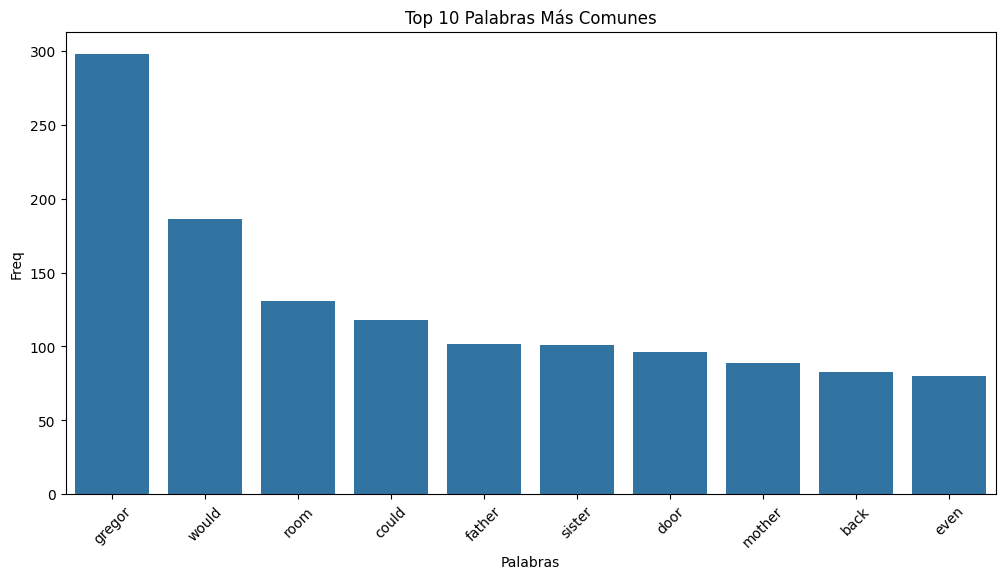

In [25]:

def plot_top_words(tokens):
    words, freqs = zip(*top10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(words), y=list(freqs))
    plt.title('Top 10 Palabras Más Comunes')
    plt.xlabel('Palabras')
    plt.ylabel('Freq')
    plt.xticks(rotation=45)
    plt.show()

plot_top_words(lemmaToken)

### Insights:

- Gregor es la palabra más repetida. Hace total sentido ya que es el personaje principal.
- would/could son verbos modales. Los podemos ver como deseos/condiciones.
- salen 3 miembros de su familia: father/mother/sister. Hace sentido por la narrativa, con sus sombras y luces de su dinámica familiar.

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import fetch_20newsgroups

In [37]:
labels = ['Kafka', 'No Kafka']
kafka_text = ' '.join(lemmaToken)

# Texto sample que NO es kafka-niano:
notis = fetch_20newsgroups(subset='train', categories=['sci.space', 'rec.autos', 'talk.politics.mideast'], remove=('headers', 'footers', 'quotes'))
noKafka = notis.data[:len(kafka_text.split())]

texts = [kafka_text] * len(noKafka) + noKafka
labels = ['Kafka'] * len(noKafka) + ['No Kafka'] * len(noKafka)


def preprocess_data(texts):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

def train_model(X, y):
    model = MultinomialNB()
    model.fit(X, y)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))


X, vectorizer = preprocess_data(texts)
y = np.array(labels)

print(X)
print(y)

  (0, 7613)	0.0018215266004570187
  (0, 6269)	0.0018209130470982085
  (0, 2418)	0.0018117514418852382
  (0, 18909)	0.0018227547566816095
  (0, 4762)	0.001791866085223996
  (0, 4357)	0.0018227547566816095
  (0, 21325)	0.0018221405035185314
  (0, 17268)	0.0018221405035185314
  (0, 14423)	0.0018233693603457984
  (0, 18242)	0.0018129684961302845
  (0, 14467)	0.001817239048451445
  (0, 5438)	0.001806291652086781
  (0, 18571)	0.001819074481259579
  (0, 9275)	0.0018227547566816095
  (0, 7963)	0.0018129684961302845
  (0, 5975)	0.0018227547566816095
  (0, 22606)	0.0018233693603457984
  (0, 6694)	0.0017711691809220893
  (0, 23713)	0.0036467387206915967
  (0, 12059)	0.0018221405035185314
  (0, 13743)	0.0018221405035185314
  (0, 22415)	0.0017865059215322267
  (0, 24052)	0.0018215266004570187
  (0, 10498)	0.00182029984304392
  (0, 7622)	0.0018056867136309659
  :	:
  (3500, 23236)	0.08123696954627165
  (3500, 9246)	0.08248297776146872
  (3500, 5533)	0.0836485634271844
  (3500, 10473)	0.0826478266807

In [38]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model = train_model(X_train, y_train)

# Evaluar el modelo
evaluate_model(model, X_test, y_test)

              precision    recall  f1-score   support

       Kafka       0.99      1.00      1.00       379
    No Kafka       1.00      0.99      1.00       322

    accuracy                           1.00       701
   macro avg       1.00      1.00      1.00       701
weighted avg       1.00      1.00      1.00       701

[[379   0]
 [  2 320]]


In [41]:
# Función para predecir nuevo texto
def predict_text(model, vectorizer, new_text):
    X_new = vectorizer.transform([new_text])
    prediction = model.predict(X_new)
    return prediction[0]

# Ejemplo de predicción con input del usuario
prueba = input("Introduce el texto para predecir si es 'Kafka' o 'No Kafka': ")
print(f"Prediction: {predict_text(model, vectorizer, prueba)}")

Introduce el texto para predecir si es 'Kafka' o 'No Kafka': Gregor went home
Prediction: Kafka


In [42]:
prueba = input("Introduce el texto para predecir si es 'Kafka' o 'No Kafka': ")
print(f"Prediction: {predict_text(model, vectorizer, prueba)}")

Introduce el texto para predecir si es 'Kafka' o 'No Kafka': Let the ruling classes tremble at a Communist revolution. The proletarians have nothing to lose but their chains. They have a world to win. Workers of the world, unite!
Prediction: No Kafka


## Resultados:

El texto predijo correctamente. El primero de Kafka, y el segundo de Marx.

Sin embargo, considero que puedo mejorar el modelo, ya que ahorita podríamos decir que está over-fitteado. Copiaré el código de arriba y le haré una validación cruzada.



In [51]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import fetch_20newsgroups
import numpy as np

notis = fetch_20newsgroups(subset='train', categories=['sci.space', 'rec.autos', 'talk.politics.mideast'], remove=('headers', 'footers', 'quotes'))
noKafka = notis.data[:1000]


kafka_text_split = kafka_text.split()
chunk_size = len(kafka_text_split) // len(noKafka)
kafka_chunks = [' '.join(kafka_text_split[i:i + chunk_size]) for i in range(0, len(kafka_text_split), chunk_size)]
kafka_chunks = kafka_chunks[:len(noKafka)]

texts = kafka_chunks + noKafka
labels = ['Kafka'] * len(kafka_chunks) + ['No Kafka'] * len(noKafka)

def preprocess_data(texts):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

def cross_validate_model(X, y):
    model = MultinomialNB()
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    return scores

def train_model(X, y):
    model = MultinomialNB()
    model.fit(X, y)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

X, vectorizer = preprocess_data(texts)
y = np.array(labels)

cross_val_scores = cross_validate_model(X, y)
print("Validación cruzada:", cross_val_scores)
print("Media de la validación cruzada:", cross_val_scores.mean())

Validación cruzada: [0.9625 0.9875 0.965  0.975  0.975 ]
Media de la validación cruzada: 0.9730000000000001


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = train_model(X_train, y_train)
evaluate_model(model, X_test, y_test)

              precision    recall  f1-score   support

       Kafka       0.96      0.99      0.98       200
    No Kafka       0.99      0.96      0.97       200

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.97       400

[[198   2]
 [  8 192]]


### Nueva versión:

- Ahora estoy usando más info en el corpus de lo "no kafka", así como también un balanceo de corpus. También, me aseguré de tener la cross validation estratificada. Regularizé el modelo y evalué en conjunto de entrenamiento / prueba.

In [53]:
# Función para predecir nuevo texto
def predict_text(model, vectorizer, new_text):
    X_new = vectorizer.transform([new_text])
    prediction = model.predict(X_new)
    return prediction[0]

# Ejemplo de predicción con input del usuario
new_text = input("Introduce el texto para predecir si es 'Kafka' o 'No Kafka': ")
print(f"Prediction: {predict_text(model, vectorizer, new_text)}")

Introduce el texto para predecir si es 'Kafka' o 'No Kafka': The Bolshevik revolution was a counter-revolution. Its first moves were to destroy and eliminate every socialist tendency that had developed in the pre-revolutionary period. Their goal was as they said; it wasn't a big secret. They regarded the Soviet Union as sort a backwater. They were orthodox Marxists, expecting a revolution in Germany. They moved toward what they themselves called "state capitalism," then they moved on to Stalinism. They called it democracy and called it socialism. The one claim was as ludicrous as the other.
Prediction: No Kafka


In [59]:
# Función para predecir nuevo texto
def predict_text(model, vectorizer, new_text):
    X_new = vectorizer.transform([new_text])
    prediction = model.predict(X_new)
    return prediction[0]

# Ejemplo de predicción con input del usuario
new_text = input("Introduce el texto para predecir si es 'Kafka' o 'No Kafka': ")
print(f"Prediction: {predict_text(model, vectorizer, new_text)}")

Introduce el texto para predecir si es 'Kafka' o 'No Kafka': Slept, awoke, slept, awoke, miserable life.
Prediction: Kafka


### Evaluación:

Clasificó correctamente. La primera frase es de Chomsky, y la segunda es de Kafka.